In [2]:
#analysis of spikes in vivo data in Watson et al, 2016.  FigS18

import scipy.io
import os
import sys
from sklearn.mixture import GaussianMixture
import matplotlib.mlab as mlab


import matplotlib.pyplot as plt
from scipy import integrate
import math
from scipy.integrate import odeint 
from tqdm import tqdm
from scipy import interpolate
from scipy.stats import gamma, shapiro, norm, expon
from scipy.optimize import curve_fit  

from collections import deque
import itertools
import numpy as np
import pandas as pd
from typing import Dict, Iterator, List, Optional, Union

import matplotlib.pyplot as plt



In [3]:
fs = 20
fs_l=15

def sleep_stats(root, cell, window):
    mat_dir = "sw_spt/Dataset1/"+root +"/"  #path for Datasets from Watson, et al. Neuron. 2016.
    sp_f = root+"_SSubtypes.mat"
    updn_f= root+"_UPDOWNINtervals.mat"
    sw_f = root + "_WSRestrictedIntervals.mat"
    
    sw_time = "WakeSleepTimePairFormat"
    cell = cell #"SiDef_CellFormat"
    
    subtype = scipy.io.loadmat(mat_dir+sp_f)
    updn_interval = scipy.io.loadmat(mat_dir+updn_f)
    sw_interval = scipy.io.loadmat(mat_dir+sw_f)

    up_durs = []
    dn_durs = []
    fr_li = []
    ISI_li = []
    
    try:
        cell_N =  len(subtype[cell][0])
        print("cells", cell_N)
        swt = sw_interval[sw_time][0]
        #waket =swt[0][0]
        sleept =swt[0][1]
        s = sleept[0]
        e = sleept[1]
        print(s)
        print(e)

        plt.figure(figsize=(23, 10))
        all_sps = []
        for i in range(cell_N):
            x = subtype[cell][:,i][0][:,0]
            y = np.ones(len(x))*i
            all_sps.append((x.flatten()).tolist())

            plt.scatter(x, y, s=0.5)

    #     plt.show()


      
        up_sp_Ns = []
     #   up_frs=[]

    #     IBI_li = []
        up_N = len(updn_interval["UPIntsTimePairFormat"])

        for n in range(up_N):
            up_pair = updn_interval["UPIntsTimePairFormat"][n]
            up_durs.append((up_pair[1]-up_pair[0])*1000)  #ms
    #         up_spt = [sp for sp in all_sps if sp>= up_pair[0] and sp<up_pair[1]]
    #         up_sp_N = len(up_spt)
    #         up_sp_Ns.append(up_sp_N)
            plt.axvspan(up_pair[0], up_pair[1], color = "coral", alpha = 0.2)

        
        for m in range(cell_N):
            up_i=0
            ISI_i =[]
            for n in range(up_N):
                up_pair = updn_interval["UPIntsTimePairFormat"][n]
                up_spt = [sp for sp in all_sps[m] if sp>= up_pair[0] and sp<up_pair[1]] #s
                up_i += len(up_spt)
                ISI_i += (np.diff(up_spt)*1000).tolist()  #ms
            fr_li.append((up_i)/(np.sum(up_durs)/1000))
            ISI_li.append(ISI_i)

       # down data
        dn_N = len(updn_interval["DNIntsTimePairFormat"])
       
        #dn_frs=[]
        for n in range(dn_N):
            dn_pair = updn_interval["DNIntsTimePairFormat"][n]
            dn_durs.append((dn_pair[1]-dn_pair[0])*1000)  #ms

        dn_fr_li = []
        for m in range(cell_N):
            dn_i=0
            for n in range(dn_N):
                dn_pair = updn_interval["DNIntsTimePairFormat"][n]
                dn_spt = [sp for sp in all_sps[m] if sp>= dn_pair[0] and sp<dn_pair[1]] #s
                dn_i += len(dn_spt)
            dn_fr_li.append((dn_i)/(np.sum(dn_durs)/1000))


            #plt.axvspan(dn_pair[0], dn_pair[1], color = "blue", alpha = 0.2)

        plt.xlim(s,e)
        plt.ylabel("Cell number", fontsize = fs)
        plt.xlabel("ms", fontsize = fs)
        plt.yticks(fontsize = fs_l)
        plt.xticks(fontsize = fs_l)
        plt.show()




        plt.figure(figsize=(10, 8))
        mean_dur_up = np.mean(up_durs)
        print("mean duration of up states (ms)", mean_dur_up)
        print("std of up states", np.std([i for i in up_durs]))
        print("mean firing rate at up-state", (np.mean(fr_li)))
        plt.hist(up_durs, bins=100, alpha = 0.4, label="up")
       # plt.ylabel("counts", fontsize = fs)
       # plt.xlabel("Up-state duration(ms)", fontsize = fs)

        mean_dur_dn = np.mean(dn_durs)
        print("mean duration of down states (ms)", mean_dur_dn)
        print("std of down states", np.std([i for i in dn_durs]))
        print("mean firing rate at down-state",  (np.mean(dn_fr_li)))
        plt.hist(dn_durs, bins=100, alpha = 0.4, label="down")
        plt.ylabel("counts", fontsize = fs)
        plt.xlabel("duration(ms)", fontsize = fs)
        plt.yticks(fontsize = fs_l)
        plt.xticks(fontsize = fs_l)
        plt.legend(fontsize = fs_l)
        plt.show()
    
    except:
        print("cell file not found")
    return up_durs, dn_durs, ISI_li, fr_li  #, all_sps

def wake_stats(root, cell, window):
    mat_dir = "sw_spt/Dataset1/"+root +"/"
    sp_f = root+"_SSubtypes.mat"
   # up_f= root+"_UPDOWNINtervals.mat"
    sw_f = root + "_WSRestrictedIntervals.mat"
    sw_time = "WakeSleepTimePairFormat"
    cell =cell # "SiDef_CellFormat" #"Se_CellFormat"
    
    subtype = scipy.io.loadmat(mat_dir+sp_f)
   # up_interval = scipy.io.loadmat(mat_dir+up_f)
    sw_interval = scipy.io.loadmat(mat_dir+sw_f)
    
    fr_li = []
    ISI_li = []
    try:
        cell_N =  len(subtype[cell][0])
        swt = sw_interval[sw_time][0]
        #waket =swt[0][0]
        waket =swt[0][0]
        s = waket[0]
        e = waket[1]
        print(s)
        print(e)

        subtype = scipy.io.loadmat(mat_dir+sp_f)
        cell_N =  len(subtype[cell][0])
        plt.figure(figsize=(23, 10))
        all_sps = []
        for i in range(cell_N):
            x = subtype[cell][:,i][0][:,0]
            y = np.ones(len(x))*i
            all_sps.append((x.flatten()).tolist())

            plt.scatter(x, y, s=0.5)

        plt.xlim(s,e)
        plt.ylabel("Cell number", fontsize = fs)
        plt.xlabel("sec", fontsize = fs)
        plt.yticks(fontsize = fs_l)
        plt.xticks(fontsize = fs_l)
        plt.show()

        fr_li = []
        ISI_li = []
        for m in range(cell_N):
            up_spt = [sp for sp in all_sps[m] if sp>= s and sp < e] #s

            ISI_i = (np.diff(up_spt)*1000).tolist() #  ms
            fr_li.append(len(up_spt)/(e-s))

            ISI_li.append(ISI_i)


        print("mean firing rate at wake", np.mean(fr_li))
        
    
    except:
        print("cell file not found")
        
    return ISI_li, fr_li
        
# ISI fitting (up state in sleep)
from scipy.stats import expon, gamma
import matplotlib.pyplot as plt




#ISI lognormal sleep
import itertools
def log_fit(ISI_li, bins, graph = True, loop =False):
    if loop ==True:
        ISI_li = list(itertools.chain.from_iterable(ISI_li))
    
    ISI_log = np.log10(ISI_li)
    

    mean_log = np.mean(ISI_log)   # 平均
    std_log = np.std(ISI_log)     # 標準偏差
    print("log mean: {} ,SD: {}".format(mean_log, std_log))
#     bin_list = [6-(-1)/bins*i for i in range(bins)]
#     print(bin_list)
#     counts, x_b = np.histogram(ISI_log, bins = bin_list)
#     c_norm = counts/sum(counts)
#     print("counts", counts)
#     print("c_norm", c_norm)
    
#     x0 = np.linspace(-2,6,200)
#     y0 = norm.pdf(x0, mean_log, std_log)*(np.ones(len(x0))/len(ISI_log))
    a,b, _ =  plt.hist(ISI_log, bins=bins)
    plt.close()
    n = len(ISI_log) # データ点の数
    b_width = b[1] - b[0] # ビンの間隔
    a /= n * b_width # 高さを（データ数×ビンの幅）で割る
    plt.bar(x=b[:-1], height=a, width=b_width, align="edge") # 再表示
#     plt.plot(b, norm.pdf(b, loc=mu, scale=sigma))
    
    
#     if graph == True:
#         plt.figure(figsize=(10, 8))

# #         plt.hist(ISI_log, bins=bins, density = True, alpha = 0.4, label = "data")
# #         plt.hist(ISI_log, bins, weights = np.ones(len(ISI_log))/len(ISI_log))
#         _,b, _ = plt.hist(ISI_log, bins=bins, density=True)
#         plt.plot(b, norm.pdf(b, mean_log, std_log))
    
# #         plt.plot(x0, y0, label='fitted')

#         plt.ylabel("", fontsize = fs)
#         plt.xlabel("log10((ms))", fontsize = fs)
#         plt.yticks(fontsize = fs_l)
#         plt.xticks(fontsize = fs_l)
#         plt.legend(fontsize = fs_l)
#         # plt.xlim(0,1000)
#         # plt.ylim(0,0.02)
    plt.show()
    
    return mean_log, std_log

def log_fit2(ISI_li, bins, saven, graph = True, loop =False):
    if loop ==True:
        ISI_li = list(itertools.chain.from_iterable(ISI_li))
    
    ISI_log  = np.log10(ISI_li)
    
#     pv = shapiro(ISI_log)
#     print('p value:', pv.pvalue)
    
   

    mean_log = np.mean(ISI_log)   # 平均
    std_log = np.std(ISI_log)     # 標準偏差
    print("log mean: {} ,SD: {}".format(mean_log, std_log))
    # print("α", (mean)**2/var)
    # print("β", mean/var)
    x0 = np.linspace(-2,6,200)
    #y0 = stats.expon.pdf(x0, 0, mean)
    # la=(mean**3)/std
    # y0 = stats.invgauss.pdf(x0, mean, 0, 1/la)  #inverse　ガウス分布
    #y0 = gamma.pdf(x0, (mean)**2/var,0, scale=var/mean) 
    y0 = norm.pdf(x0, mean_log, std_log)
    
    if graph == True:
        plt.figure(figsize=(10, 8))
        # ISI_log = np.log10(ISI_li2)
        plt.hist(ISI_log, bins=bins, density = True, alpha = 0.4, label = "data", color="steelblue")
        plt.plot(x0, y0, label='fitted', c="darkorange")

#         plt.ylabel("", fontsize = fs)
#         plt.xlabel("log10((ms))", fontsize = fs)
        plt.yticks(fontsize = fs_l)
        plt.xticks(fontsize = fs_l)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)

        plt.xlabel('',fontsize = fs)
        plt.ylabel("", fontsize = fs) 
        
        ax = plt.gca()
        ax.axes.xaxis.set_ticklabels([])
        ax.axes.yaxis.set_ticklabels([])

        plt.savefig(saven)


     
        # plt.xlim(0,1000)
        # plt.ylim(0,0.02)
        plt.show()
    
    return mean_log, std_log
    
def linear_plot(x1, y1):
    def func(x, a, b):
        y=a*x+b
        return y

    popt, pcov = curve_fit(func,x1,y1) # poptは最適推定値、pcovは共分散
    #popt
    print("a", popt[0])
    print("b", popt[1])
    y_pred = func(x1, popt[0], popt[1])

    min_esq = np.sum((y1-y_pred)**2)
    tss = np.sum((y1-np.mean(y1))**2)#total sum of squares = tss
    r_squared = 1 - (min_esq / tss)
    print("R", r_squared)


    plt.figure(figsize=(10, 8))
    plt.scatter(x1, y1, label = "data", c="red")
    plt.plot(x1, y_pred, label="fitted")
    plt.ylabel("SD", fontsize = fs)
    plt.xlabel("mean", fontsize = fs)
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs_l)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
    
    #     plt.xlabel('',fontsize = fs)
#     plt.ylabel("", fontsize = fs)    
    
#     ax = plt.gca()
#     ax.axes.xaxis.set_ticklabels([])
#     ax.axes.yaxis.set_ticklabels([])
    
#     plt.savefig("homecage_ex_sp_{}_N{}_ex{}-{}{}.SVG".format(date_i,NE, ex_w, ex_s, bifur))
    
    
    plt.show()
    print(popt)
    
def linear_plot2(x1, y1, saven):
    def func(x, a, b):
        y=a*x+b
        return y

    popt, pcov = curve_fit(func,x1,y1) # poptは最適推定値、pcovは共分散
    #popt
    print("a", popt[0])
    print("b", popt[1])
    y_pred = func(x1, popt[0], popt[1])

    min_esq = np.sum((y1-y_pred)**2)
    tss = np.sum((y1-np.mean(y1))**2)#total sum of squares = tss
    r_squared = 1 - (min_esq / tss)
    print("R", r_squared)


    plt.figure(figsize=(10, 8))
    plt.scatter(x1, y1, label = "data", c="red")
    plt.plot(x1, y_pred, label="fitted")
    plt.ylabel("SD", fontsize = fs)
    plt.xlabel("mean", fontsize = fs)
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs_l)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
    
    plt.xlabel('',fontsize = fs)
    plt.ylabel("", fontsize = fs)    
    ax = plt.gca()
    ax.axes.xaxis.set_ticklabels([])
    ax.axes.yaxis.set_ticklabels([])
    
    plt.savefig(saven)
     
    
    plt.show()
    print(popt)
    
def ISI_all_th(fr_th, fr_li, ISI_li, bins, pdf):
    fr_li_new = []
    ISI_li_new =[]
    for n, fr in enumerate(fr_li):
        #print(fr)
        if fr < fr_th:
            fr_li_new.append(fr)
            ISI_li_new.append(ISI_li[n])
    print("samples: ", len(ISI_li_new))
    if pdf == "log":
        log_ISI_graph(ISI_li_new, bins, False, True)
    elif pdf == "gamma"or pdf =="expon":
        ex_gamma_fit(ISI_li_new, bins,  20000, pdf, False, True)
        


def ISI_df(path, cell, window):
    root_li = os.listdir(path=path)


    cell = cell#"SeDef_CellFormat"#"Se_CellFormat"
    fs=25
    fs_l = 20
    window = 100 # ms
    up_durs_li = []
    dn_durs_li = []
    up_Ns = 0
    dn_Ns = 0
    

    ISI_all=[]
    ISI_all_w=[]
    frs = []

    
    frs_w = []

    ISI_sum = 0
    ISI_N = 0
    ISI_sum_w = 0
    ISI_N_w = 0
    for n, root in enumerate(root_li):
#         if n>0:
#             continue
        up_durs, dn_durs, ISI_li, fr_li = sleep_stats(root,cell, window)
        ISI_li_w, fr_li_w = wake_stats(root,cell, window)
        up_durs_li += up_durs
        dn_durs_li += dn_durs
        up_Ns += len(up_durs)
        dn_Ns += len(dn_durs)
        
        ISI_sum += np.sum(np.sum(ISI_li))
        ISI_N += len(list(itertools.chain.from_iterable(ISI_li)))
        ISI_sum_w += np.sum(np.sum(ISI_li_w))
        ISI_N_w += len(list(itertools.chain.from_iterable(ISI_li_w)))

#         if len(up_durs)!=0:
#             up_log_mean, up_log_std = log_fit(up_durs, 50, False, False)
#         if len(dn_durs)!=0:   
#             dn_log_mean, dn_log_std = log_fit(dn_durs, 50, False, False)

#         up_means.append(up_log_mean)
#         up_stds.append(up_log_std)
#         dn_means.append(dn_log_mean)
#         dn_stds.append(dn_log_std)

        for n, ISI_i in enumerate(ISI_li):
            print(len(ISI_i))
            ISI_i2 = np.array(ISI_i)
#             mean, SD = log_fit(ISI_i2, 50, False)
            ISI_all.append(ISI_i2)
           


        for n, ISI_i_w in enumerate(ISI_li_w):
            print(len(ISI_i_w))
            ISI_i2_w = np.array(ISI_i_w) 
            ISI_all_w.append(ISI_i2_w)

        frs += fr_li
        frs_w += fr_li_w
    return  ISI_all, ISI_all_w,  frs, frs_w

def log_df(path, cell, window):
    root_li = os.listdir(path=path)


    cell = cell#"SeDef_CellFormat"#"Se_CellFormat"
    fs=25
    fs_l = 20
    window = 100 # ms
    up_durs_li = []
    dn_durs_li = []
    up_Ns = 0
    dn_Ns = 0
    
    up_means=[]
    up_stds=[]
    dn_means=[]
    dn_stds=[]

    ISI_means = []
    ISI_SDs = []
    frs = []

    ISI_means_w = []
    ISI_SDs_w = []
    frs_w = []

    ISI_sum = 0
    ISI_N = 0
    ISI_sum_w = 0
    ISI_N_w = 0
    for root in root_li:
        up_durs, dn_durs, ISI_li, fr_li = sleep_stats(root,cell, window)
        ISI_li_w, fr_li_w = wake_stats(root,cell, window)
        up_durs_li += up_durs
        dn_durs_li += dn_durs
        up_Ns += len(up_durs)
        dn_Ns += len(dn_durs)
        
        ISI_sum += np.sum(np.sum(ISI_li))
        ISI_N += len(list(itertools.chain.from_iterable(ISI_li)))
        ISI_sum_w += np.sum(np.sum(ISI_li_w))
        ISI_N_w += len(list(itertools.chain.from_iterable(ISI_li_w)))

        if len(up_durs)!=0:
            up_log_mean, up_log_std = log_fit(up_durs, 50, False, False)
        if len(dn_durs)!=0:   
            dn_log_mean, dn_log_std = log_fit(dn_durs, 50, False, False)

        up_means.append(up_log_mean)
        up_stds.append(up_log_std)
        dn_means.append(dn_log_mean)
        dn_stds.append(dn_log_std)

        for n, ISI_i in enumerate(ISI_li):
            print(len(ISI_i))
            ISI_i2 = np.array(ISI_i)
            mean, SD = log_fit(ISI_i2, 50, False)
            ISI_means.append(mean)
            ISI_SDs.append(SD)


        for n, ISI_i_w in enumerate(ISI_li_w):
            print(len(ISI_i_w))
            ISI_i2_w = np.array(ISI_i_w) 
            mean_w, SD_w = log_fit(ISI_i2_w, 50, False)
            ISI_means_w.append(mean_w)
            ISI_SDs_w.append(SD_w)

        frs += fr_li
        frs_w += fr_li_w
    df_dur = pd.DataFrame(list(zip(up_means, up_stds, dn_means,dn_stds)), columns = ["up_mean", "up_SD", "dn_mean", "dn_SD"])
    
    print("mean_up_dur(ms)", np.sum(up_durs_li)/up_Ns)
    print("mean_dn_dur(ms)", np.sum(dn_durs_li)/dn_Ns)
    print("mean_ISI_sleep(ms)", ISI_sum/ISI_N)
    print("mean_ISI_wake(ms)", ISI_sum_w/ISI_N_w)
    
    
    return df_dur,ISI_means, ISI_SDs, ISI_means_w, ISI_SDs_w, frs, frs_w

def ISI_log_graph(ISI_measns, ISI_SDs, frs, savepath):
    nan_i = np.where(~np.isnan(ISI_means))[0]
    means = np.take(ISI_means, nan_i)
    SDs = np.take(ISI_SDs, nan_i)
    frs = np.take(frs, nan_i)

    p="sw_spt"

    df_ISI = pd.DataFrame(list(zip(frs, ISI_means, ISI_SDs)), columns = ["FR", "mean", "SD"] )
    print(df_ISI)

    df_ISI.to_excel(p+"/"+savepath+".xlsx")

    print("cells", len(df_ISI))
    #plt.scatter(means, SDs)
    linear_plot(np.array(ISI_means), np.array(ISI_SDs))

    return df_ISI

In [ ]:
#collect and save spikes of excitatory neurons 

datasets ="all"
cell ="SeDef_CellFormat"  #"SeDef_CellFormat"  or "Se_CellFormat"

dataset_name= "Dataset1"


if cell =="SeDef_CellFormat": #"SeDef_CellFormat"  or "Se_CellFormat"
    cell_def ="sedef"
elif cell =="Se_CellFormat":
    cell_def ="se"
    
p = 'sw_spt'  
path = p + "/{}".format(dataset_name) # path for Datasets from Watson et al. Neuron. 2016.
window = 100 # ms
df_dur,ISI_means, ISI_SDs, ISI_means_w, ISI_SDs_w, frs, frs_w = log_df(path, cell, window)

savepath = "updn_log_{}_sedef".format(datasets)


df_dur.to_excel(p+"/"+savepath+".xlsx")  #up_means, up_stds, dn_means,dn_stds 


#collect and save ISI from excitatory neurons 
ISI_all, ISI_all_w,  frs, frs_w = ISI_df(path, cell, window)

ISI_all_li=list(itertools.chain.from_iterable(ISI_all))
ISI_all_li = np.save(p+"ISI_{}_{}_sleep".format(datasets,cell_def), ISI_all_li)

ISI_all_w_li=list(itertools.chain.from_iterable(ISI_all_w))
np.save(p+"ISI_{}_{}_wake".format(datasets,cell_def), ISI_all_w_li)

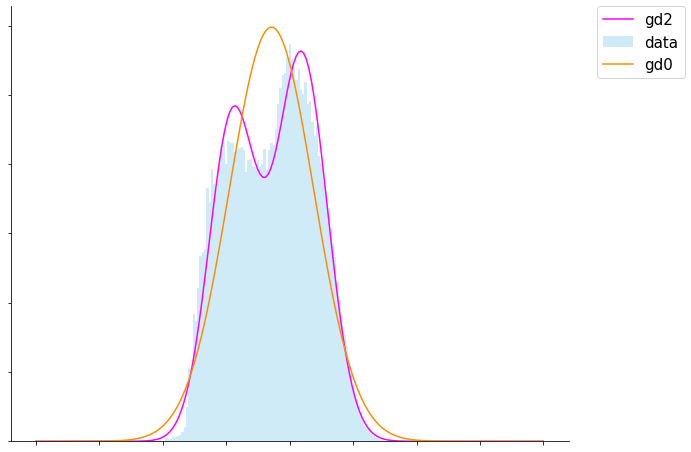

In [4]:
#gaussian fitting for ISI distribution of NREM sleep


ISI_all_li = np.load(p+"ISI_{}_{}_sleep.npy".format(datasets,cell_def))
saven  = "ISI_sleep_hist_logfit.SVG"

# fitting by GaussianMixture 
gmm = GaussianMixture(
    n_components=2,
    covariance_type='spherical'
).fit(
    np.log10(ISI_all_li).reshape(-1, 1)  # 次元数2を入力とするため変形
)

x = np.linspace(-2,6,200)
gd1 = norm.pdf(x, gmm.means_[0, -1], np.sqrt(gmm.covariances_[0]))
gd2 = norm.pdf(x, gmm.means_[1, -1], np.sqrt(gmm.covariances_[1]))


mean_log = np.mean(np.log10(ISI_all_li))   # 平均
std_log = np.std(np.log10(ISI_all_li))     # 標準偏差

y0 = norm.pdf(x, mean_log, std_log)

plt.figure(figsize=(10, 8))
    
plt.plot(x, gmm.weights_[1] * gd2 + gmm.weights_[0] * gd1, label='gd2', c="magenta")

plt.hist(np.log10(ISI_all_li), bins=100, density = True, alpha = 0.4, label = "data", color="skyblue")

plt.plot(x, y0, label='gd0', c="darkorange")

plt.ylabel("", fontsize = fs)
plt.xlabel("log10((ms))", fontsize = fs)
plt.yticks(fontsize = fs_l)
plt.xticks(fontsize = fs_l)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)


plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# ax = plt.gca()
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])

plt.savefig(saven)


plt.show()

log mean: 2.1290015369586963 ,SD: 0.7272805188677189


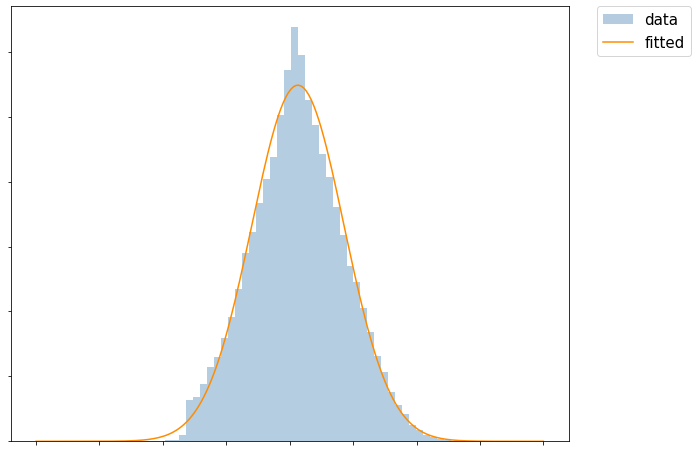

243800

In [13]:
#gaussian fitting for ISI distribution of wake states
#All excitatory neurons collection 
datasets ="all"
cell ="SeDef_CellFormat"  #"SeDef_CellFormat"  or "Se_CellFormat"

if datasets == "all":
    dataset_name= "Dataset1"
elif datasets =="homecage":
    dataset_name ="homecage"

if cell =="SeDef_CellFormat": #"SeDef_CellFormat"  or "Se_CellFormat"
    cell_def ="sedef"
elif cell =="Se_CellFormat":
    cell_def ="se"

#
ISI_all_w_li = np.load(p+"ISI_{}_{}_wake.npy".format(datasets,cell_def))
saven = "ISI_{}_{}_wake_logfit3.SVG".format(datasets,cell_def)

# mean, SD = log_fit(ISI_all_w_li, 50, True)
mean, SD = log_fit2(ISI_all_w_li, 50, saven, True)


len(ISI_all_w_li)

a 0.33549896272579843
b -0.6834317532115161
R 0.8310396853128884


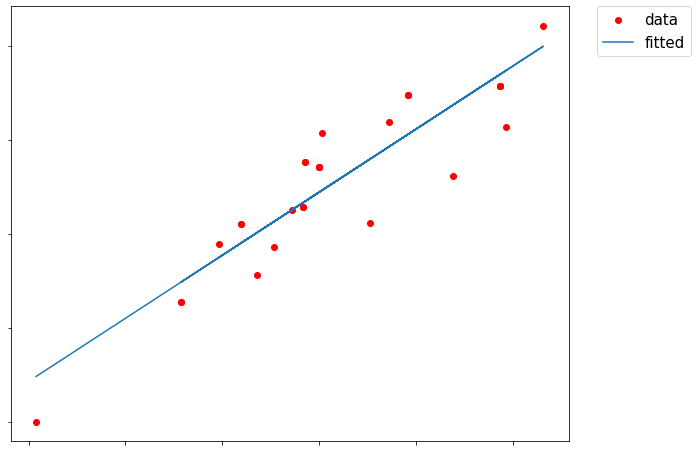

[ 0.33549896 -0.68343175]
a 0.2411794354506779
b -0.3678976466981352
R 0.9157783533023853


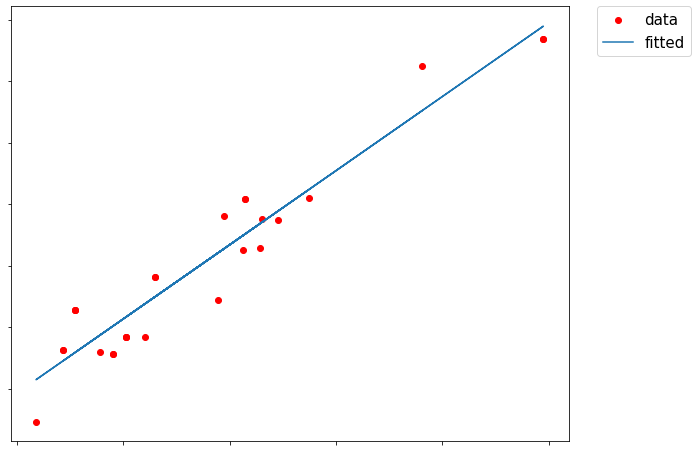

[ 0.24117944 -0.36789765]
a -0.6946612207531141
b 4.155671871348822
R 0.4486382235509323


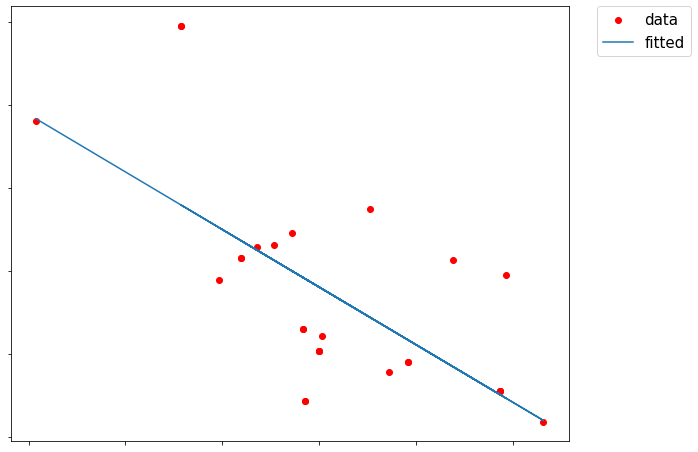

[-0.69466122  4.15567187]


In [6]:
#linear regression analysis for up and down states in sleep

savepath = "updn_log_{}_sedef".format(datasets)

df_dur.to_excel(p+"/"+savepath+".xlsx")  #up_means, up_stds, dn_means,dn_stds 
# 
df_dur = pd.read_excel(p+"/"+savepath+".xlsx")

#linear_plot(df_dur["up_mean"], df_dur["up_SD"])
linear_plot2(df_dur["up_mean"], df_dur["up_SD"], "{}_{}_up_meanSD.SVG".format(datasets, cell_def))
#linear_plot(df_dur["dn_mean"], df_dur["dn_SD"])
linear_plot2(df_dur["dn_mean"], df_dur["dn_SD"], "{}_{}_dn_meanSD.SVG".format(datasets, cell_def))
#linear_plot(df_dur["up_mean"],df_dur["dn_mean"])
linear_plot2(df_dur["up_mean"],df_dur["dn_mean"], "{}_{}_updn_mean.SVG".format(datasets, cell_def))

cells 101
a -0.18547334228500306
b 0.9412408336202887
R 0.2164633873115277


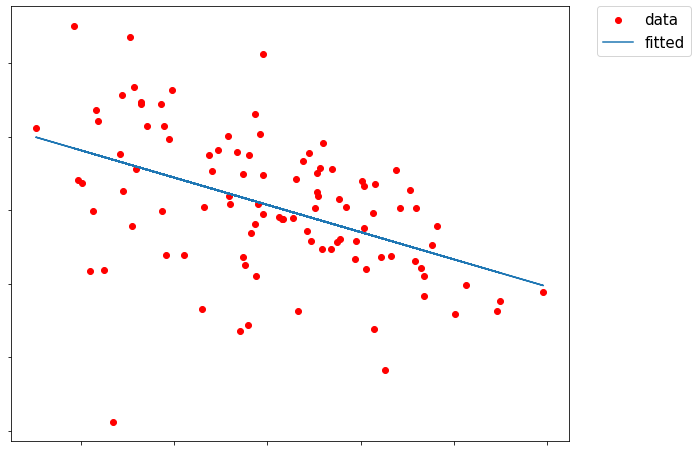

[-0.18547334  0.94124083]
     Unnamed: 0        FR      mean        SD
0             0  1.022864  1.582610  0.539386
1             1  0.531945  1.783016  0.703591
2             2  0.881562  2.104783  0.627595
3             3  0.779721  1.877161  0.666968
4             4  1.806619  1.715824  0.700519
..          ...       ...       ...       ...
96           96  0.450650  1.506182  0.836075
97           97  1.047665  1.779354  0.608196
98           98  0.192585  1.484114  0.676161
99           99  0.439095  1.384385  0.850456
100         100  3.848827  1.469168  0.312670

[101 rows x 4 columns]


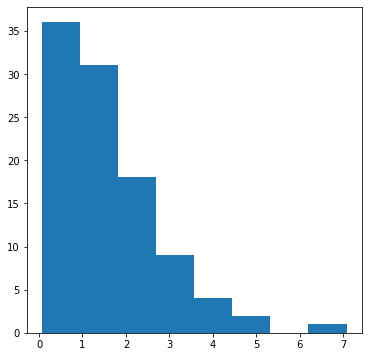

In [7]:
# #linear regression analysis for ISI in sleep
savepath = "sleep_log_ISI_{}_{}".format(datasets, cell_def)


nan_i = np.where(~np.isnan(ISI_means))[0]
means = np.take(ISI_means, nan_i)
SDs = np.take(ISI_SDs, nan_i)
frs2 = np.take(frs, nan_i)

df_ISI = pd.DataFrame(list(zip(frs2, means, SDs)), columns = ["FR", "mean", "SD"] )

df_ISI.to_excel(p+"/"+savepath+".xlsx")


# df_ISI = pd.read_excel(p+"/"+savepath+".xlsx")

print("cells", len(df_ISI))

#linear_plot(df_ISI["mean"], df_ISI["SD"])
linear_plot2(df_ISI["mean"], df_ISI["SD"], "{}_{}_ISI_sleep_mean-SD.SVG".format(datasets, cell_def))

print(df_ISI)

plt.figure(figsize=(6,6))
plt.hist(df_ISI["FR"], bins=8)
plt.show()

cells 101
a 0.030105243087155342
b 0.6385528124315202
R 0.007745460577312735


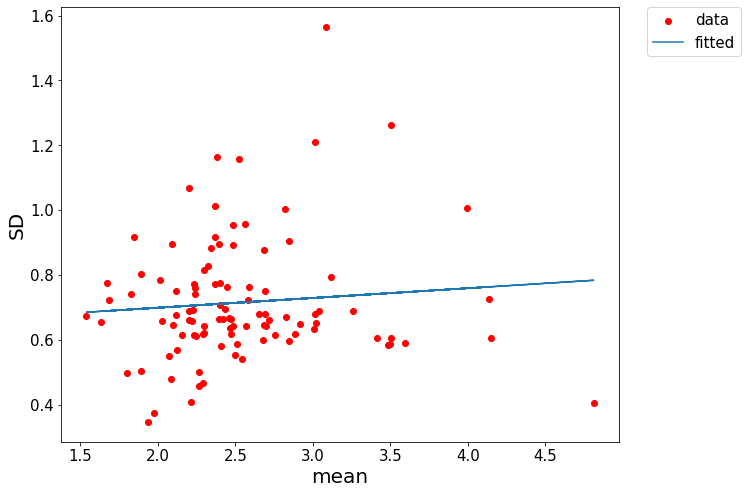

[0.03010524 0.63855281]
a 0.030105243087155342
b 0.6385528124315202
R 0.007745460577312735


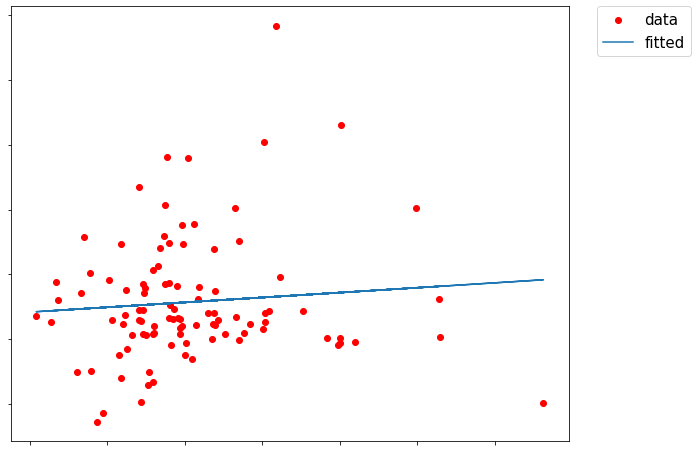

[0.03010524 0.63855281]


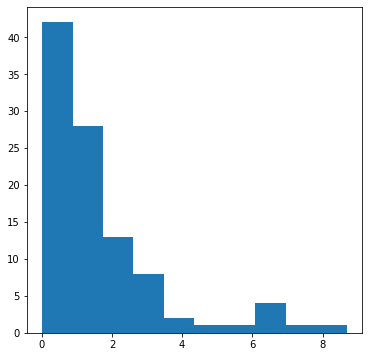

In [8]:
#linear regression analysis for ISI in wake
savepath = "wake_log_ISI_{}_{}".format(datasets, cell_def)


nan_i_w = np.where(~np.isnan(ISI_means_w))[0]
means_w = np.take(ISI_means_w, nan_i_w)
SDs_w = np.take(ISI_SDs_w, nan_i_w)
frs_w2 = np.take(frs_w, nan_i_w)


df_ISI_w = pd.DataFrame(list(zip(frs_w2, means_w, SDs_w)), columns = ["FR", "mean", "SD"] )


df_ISI_w.to_excel(p+"/"+savepath+".xlsx")

# df_ISI_w = pd.read_excel(p+"/"+savepath+".xlsx")

print("cells", len(df_ISI_w))

linear_plot(df_ISI_w["mean"], df_ISI_w["SD"])
linear_plot2(df_ISI_w["mean"], df_ISI_w["SD"], "{}_{}_ISI_wake_mean-SD.SVG".format(datasets, cell_def))


plt.figure(figsize=(6,6))
plt.hist(df_ISI_w["FR"], bins=10)
plt.show()